In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import glob
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, HTML
display(HTML("<style>body { overflow-y:scroll !important; }</style>"))

In [2]:
files=glob.glob('../Aurora_joblog/aurora_dim*.csv.gz')
df=pd.concat((pd.read_csv(f, compression='gzip') for f in files), ignore_index=True)
df['start_timestamp']= pd.to_datetime(df['start_timestamp'])
df['end_timestamp']= pd.to_datetime(df['end_timestamp'])
df.head()

,start_timestamp,end_timestamp,pbs_job_identifier,username,project_name,queue_name,runtime_seconds,nodes_used,used_node_hours,exit_code,queued_timestamp,start_date_id,end_date_id,queued_date_id,walltime_seconds,queued_wait_seconds
0,2025-08-31 23:59:16,2025-09-01 00:01:27,7495706.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,jarrahia,DNSNek,debug,102.0,1.0,0.03638,0,2025-08-31T23:57:49,20250831,20250901,20250831,2400.0,87
1,2025-08-31 23:58:02,2025-09-01 00:03:04,7495705.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,sbarwey,NekMPC,debug,272.0,1.0,0.08388,0,2025-08-31T23:56:29,20250831,20250901,20250831,3600.0,92
2,2025-09-01 00:03:13,2025-09-01 00:05:20,7495707.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,jarrahia,DNSNek,debug,98.0,1.0,0.03527,0,2025-09-01T00:01:30,20250901,20250901,20250901,2400.0,103
3,2025-08-31 21:10:31,2025-09-01 00:07:42,7495546.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,xswei,DLBurningPlasmas,small,10561.0,540.0,1594.64997,0,2025-08-31T21:08:04,20250831,20250901,20250831,12600.0,146
4,2025-08-31 20:56:57,2025-09-01 00:08:49,7493177.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,huiyuli,HIV-DRUG,tiny,11456.0,30.0,95.93333,0,2025-08-30T16:27:14,20250831,20250901,20250830,21600.0,77964


In [8]:
new_df = df.loc[
    (df["start_timestamp"] >= "2025-12-01 00:00:00") &
    (df["start_timestamp"] <= "2026-03-31 23:59:59")
]
new_df.sort_values(by = 'start_timestamp')
new_df['pbs_job_identifier']=new_df['pbs_job_identifier'].str.split('.').str[0]
new_df.tail()

,start_timestamp,end_timestamp,pbs_job_identifier,username,project_name,queue_name,runtime_seconds,nodes_used,used_node_hours,exit_code,queued_timestamp,start_date_id,end_date_id,queued_date_id,walltime_seconds,queued_wait_seconds
222005,2025-12-31 23:25:19,2025-12-31 23:47:09,8239797,jimyzhan,ElectronPhonon,tiny,1279.0,1.0,0.36388,271,2025-12-31T23:24:08,20251231,20251231,20251231,7200.0,71
222006,2025-12-31 23:47:34,2025-12-31 23:48:15,8239809,jimyzhan,ElectronPhonon,tiny,11.0,1.0,0.01138,0,2025-12-31T23:46:23,20251231,20251231,20251231,7200.0,71
222007,2025-12-31 23:42:06,2025-12-31 23:48:54,8238002,azton,FoundEpidem,tiny,356.0,97.0,10.99333,0,2025-12-29T18:25:36,20251231,20251231,20251229,21600.0,87850
222008,2025-12-31 23:50:30,2025-12-31 23:52:21,8239627,hdshin,PSFMat_2,tiny,55.0,19.0,0.58583,0,2025-12-31T15:29:09,20251231,20251231,20251231,21600.0,30080
222009,2025-12-31 23:48:13,2025-12-31 23:58:17,8239810,taeyun87,cqme25_semi,tiny,545.0,32.0,5.36888,0,2025-12-31T23:47:00,20251231,20251231,20251231,7200.0,72


In [9]:
# --- Maintenance Dates ---
maintenance_days = pd.to_datetime([
    '2025-11-24','2025-11-25',
    '2026-02-02','2026-02-03', '2026-02-04','2026-02-05',
# Daos unavailable 9-12 january
#flare upgrade week of January 12, result in multi-day outage
#reduced PVC frequency from December 8
]).sort_values()

In [10]:
#check the size of the jobs that ran weekly
#number of nodes
#node hours
bins = [1, 500, 2000, 4000, 6000, 8000, float("inf")]
labels = [
    "<500",
    "500–2000",
    "2000–4000",
    "4000–6000",
    "6000–8000",
    ">8000"
]
#new week starts Monday
new_df["week"] = new_df["start_timestamp"].dt.to_period("W").dt.start_time.dt.strftime("%Y-%m-%d")
#bin jobs by size (nodes_used)
new_df["node_bin"] = pd.cut(
    new_df["nodes_used"],
    bins=bins,
    labels=labels,
    right=False
)


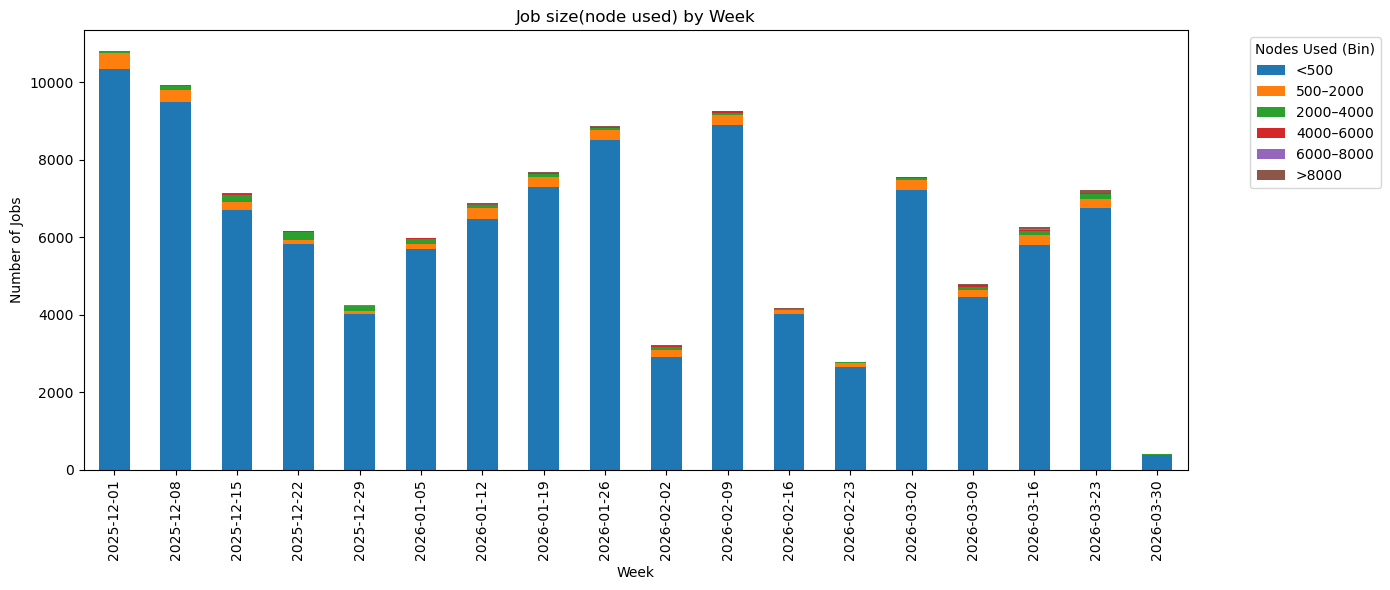

In [11]:
weekly_job_counts = (
    new_df
    .groupby(["week", "node_bin"])
    .size()  
    .unstack(fill_value=0)
)

ax = weekly_job_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6)
)

ax.set_title("Job size(node used) by Week")
ax.set_xlabel("Week")
ax.set_ylabel("Number of Jobs")
ax.legend(title="Nodes Used (Bin)", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


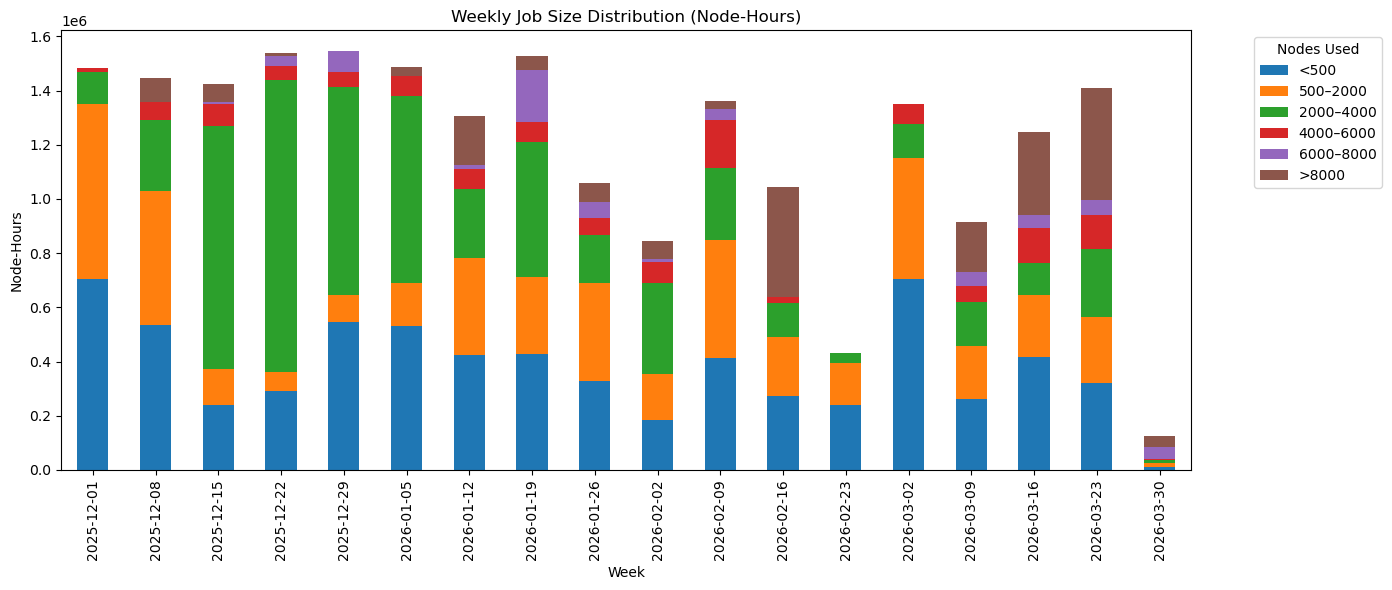

In [12]:
#node hours
weekly_node_hours = (
    new_df
    .groupby(["week", "node_bin"])["used_node_hours"]
    .sum()
    .unstack(fill_value=0)
)

ax = weekly_node_hours.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

ax.set_title("Weekly Job Size Distribution (Node-Hours)")
ax.set_xlabel("Week")
ax.set_ylabel("Node-Hours")
ax.legend(title="Nodes Used", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


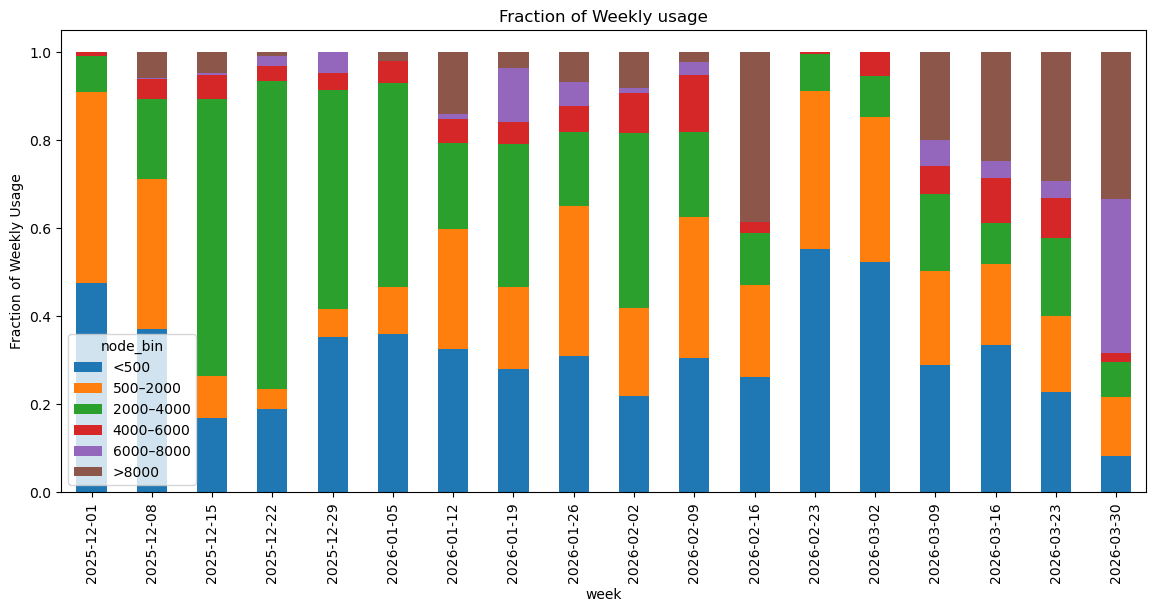

In [13]:
weekly_pct = weekly_node_hours.div(
    weekly_node_hours.sum(axis=1), axis=0
)

weekly_pct.plot(kind="bar", stacked=True, figsize=(14, 6))
plt.ylabel("Fraction of Weekly Usage")
plt.title("Fraction of Weekly usage")
plt.show()


In [14]:
#what projects are running on the >8000 nodes
#select all rows where node_bins > 8000
grt_8k = new_df[new_df['node_bin'] == '>8000']
grt_8k['project_name'].unique()

array(['Performance', 'AdvanceFusionFission', 'Operations',
       'Intel-Punchlist', 'datascience', 'HACC_aesp_CNDA', 'Intel-Aurora',
       'QuantMatManufact', 'ModCon', 'ASURA-FDPS-ML', 'TwinBlood',
       'Shamrock', 'RBC_Conv_2', 'ProbingPrimordialU', 'FusAblator',
       'NWChemEx_FMM', 'HetPolyDesign', 'candle_aesp_CNDA'], dtype=object)

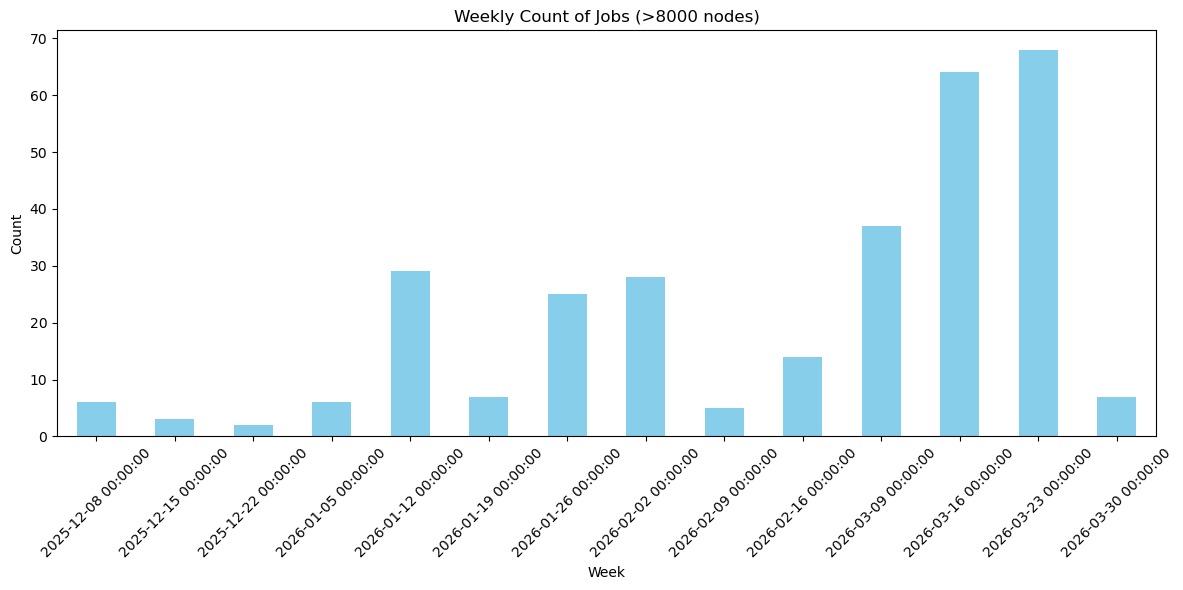

In [15]:


grt_8k['week'] = pd.to_datetime(grt_8k['week'])

# Group by week
weekly_counts = grt_8k.groupby('week').size().sort_index()

# Plot as bar
weekly_counts.plot(kind='bar', figsize=(12,6), color='skyblue')
plt.title('Weekly Count of Jobs (>8000 nodes)')
plt.xlabel('Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

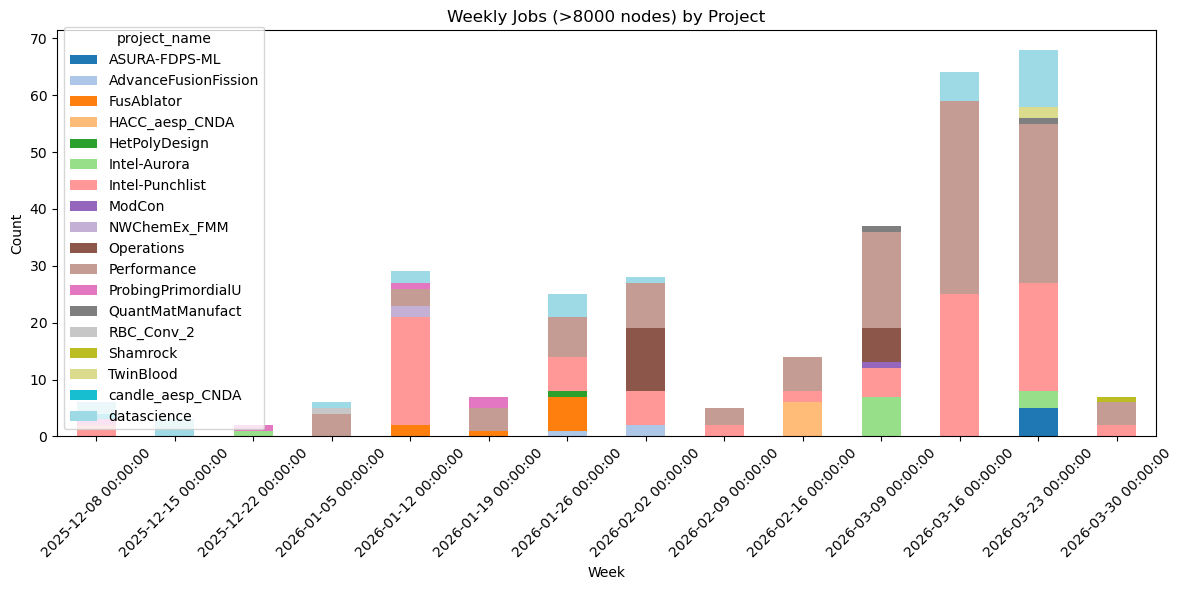

In [38]:
weekly_proj = grt_8k.groupby(['week', 'project_name']).size().unstack(fill_value=0)

weekly_proj.plot(kind='bar', colormap='tab20',stacked=True, figsize=(12,6))
plt.title('Weekly Jobs (>8000 nodes) by Project')
plt.xlabel('Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
new_df.shape

(118624, 18)

In [18]:
top_exit_codes = (
    new_df["exit_code"]
    .value_counts()
    .head(10)
    .index
)

new_df["exit_code_grouped"] = new_df["exit_code"].where(
    new_df["exit_code"].isin(top_exit_codes),
    "Others"
)


In [19]:
weekly_exit_counts = (
    new_df
    .groupby(["week", "exit_code_grouped"])
    .size()
    .unstack(fill_value=0)
)


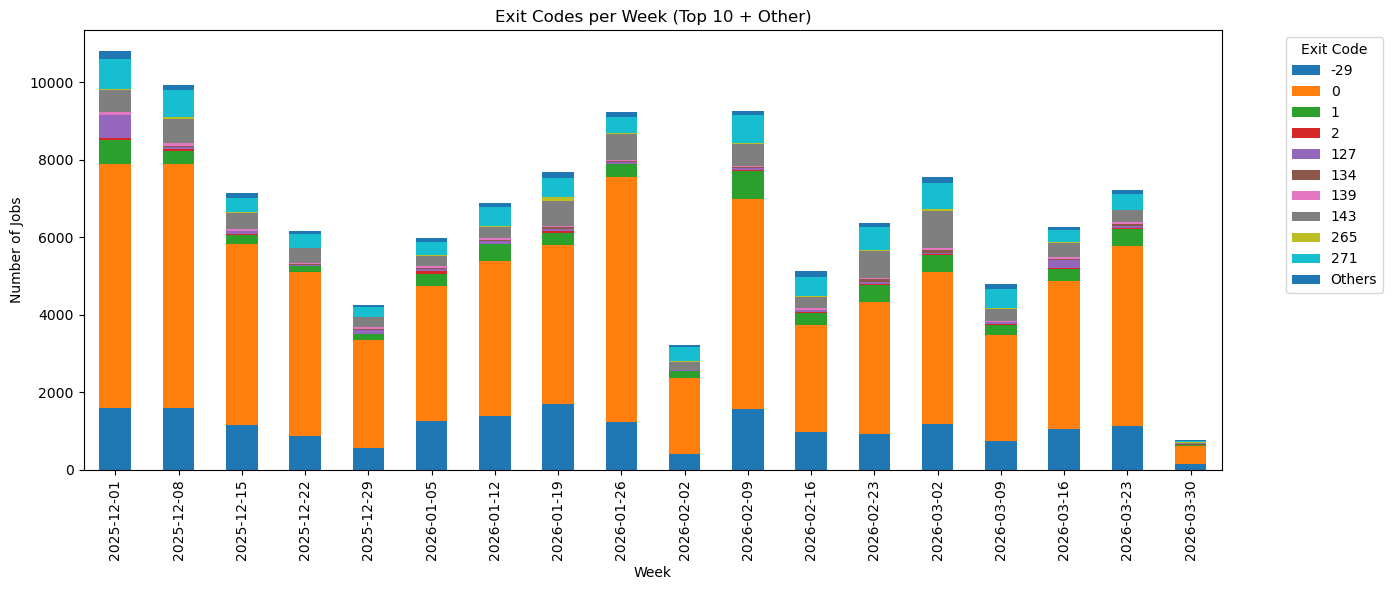

In [20]:
weekly_exit_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6)
)

plt.title("Exit Codes per Week (Top 10 + Other)")
plt.xlabel("Week")
plt.ylabel("Number of Jobs")
plt.legend(
    title="Exit Code",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [21]:
top_exit_codes = (
    new_df["exit_code"]
    .value_counts()
    .head(10)
    .index
)
new_df["exit_code_grouped"] = new_df["exit_code"].where(
    new_df["exit_code"].isin(top_exit_codes),
    "Other"
)
nonzero_df = new_df[new_df["exit_code"] != 0]


In [22]:
weekly_exit_counts = (
    nonzero_df
    .groupby(["week", "exit_code_grouped"])
    .size()
    .reset_index(name="job_count")
)


In [23]:
import plotly.express as px

fig = px.bar(
    weekly_exit_counts,
    x="week",
    y="job_count",
    color="exit_code_grouped",
    title="Top 10 non-zero exit codes + others)",
    labels={
        "week": "Week",
        "job_count": "Number of Jobs",
        "exit_code_grouped": "Exit Code"
    }
)

fig.update_layout(
    barmode="stack",
    xaxis_tickangle=-45,
    legend_title_text="Exit Code",
)

fig.show()
fig.write_html("non_zero_exit_codes_per_week.html")


In [24]:
#percentage of jobs with non-zero exit codes per week

#  percentages per week
weekly_exit_counts["percentage"] = (
    weekly_exit_counts["job_count"] /
    weekly_exit_counts.groupby("week")["job_count"].transform("sum")
) * 100

# Plot
import plotly.express as px

fig = px.bar(
    weekly_exit_counts,
    x="week",
    y="percentage",
    color="exit_code_grouped",
    title="Percentage of Top 10 Non-Zero Exit Codes per Week",
    labels={
        "week": "Week",
        "percentage": "Percentage (%)",
        "exit_code_grouped": "Exit Code"
    }
)

fig.update_layout(
    barmode="stack",
    xaxis_tickangle=-45,
    legend_title_text="Exit Code",
)

fig.show()
fig.write_html("non_zero_exit_codes_percentage_per_week.html")

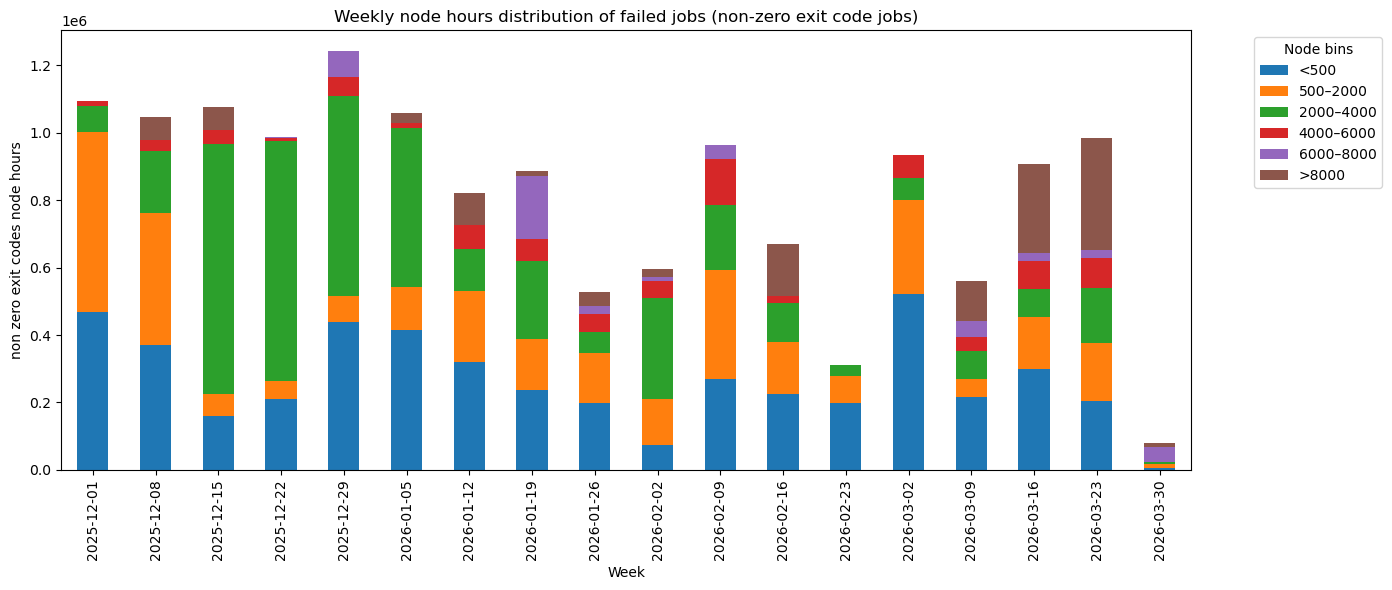

In [25]:
# Percentage of non-zero exit code jobs within each size bucket
weekly_node_hours = (
    nonzero_df
    .groupby(["week", "node_bin"])["used_node_hours"]
    .sum()
    .unstack(fill_value=0)
)

ax = weekly_node_hours.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

ax.set_title("Weekly node hours distribution of failed jobs (non-zero exit code jobs)")
ax.set_xlabel("Week")
ax.set_ylabel("non zero exit codes node hours")
ax.legend(title="Node bins", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

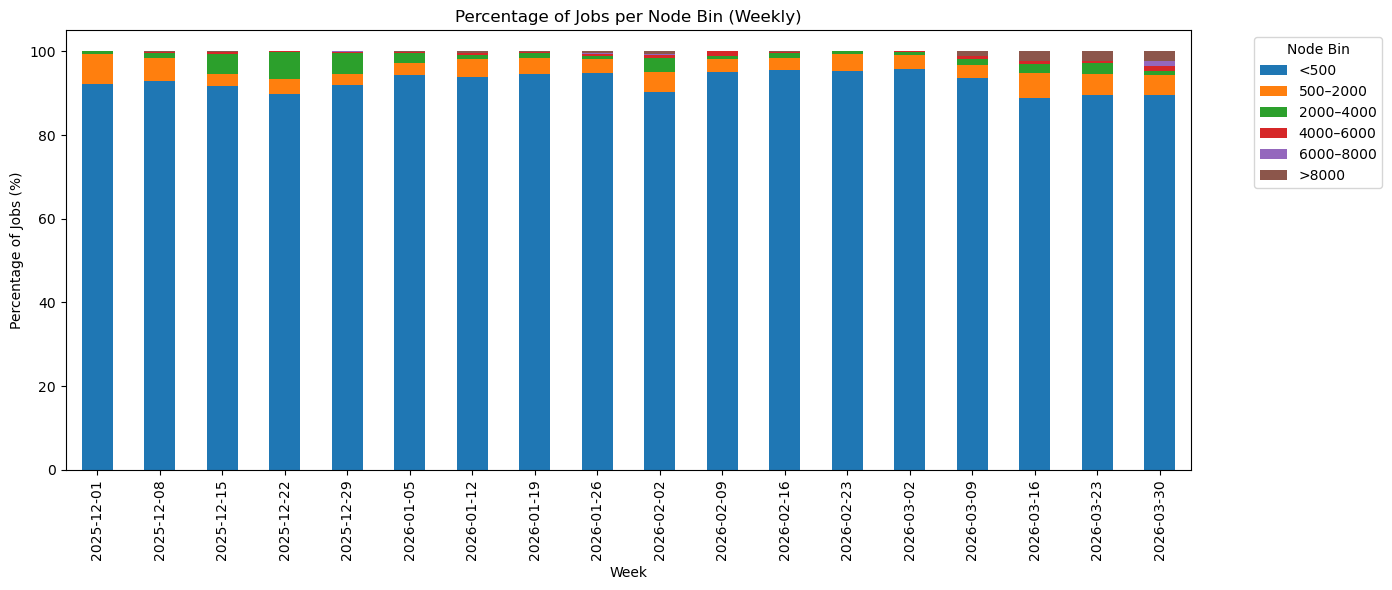

In [26]:
# Count jobs per week per node_bin
weekly_counts = (
    nonzero_df
    .groupby(["week", "node_bin"])
    .size()
    .unstack(fill_value=0)
)

weekly_pct = (
    weekly_counts.div(weekly_counts.sum(axis=1), axis=0) * 100
)

ax = weekly_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

ax.set_title("Percentage of Jobs per Node Bin (Weekly)")
ax.set_xlabel("Week")
ax.set_ylabel("Percentage of Jobs (%)")
ax.legend(
    title="Node Bin",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Projects ##

In [27]:
# For each week, plot how many jobs ran for the top 10 most common projects
top_projects = (
    new_df["project_name"]
    .value_counts()
    .head(10)
    .index
)

weekly_project_counts = (
    new_df[new_df["project_name"].isin(top_projects)]
    .groupby(["week", "project_name"])
    .size()
    .reset_index(name="job_count")
)


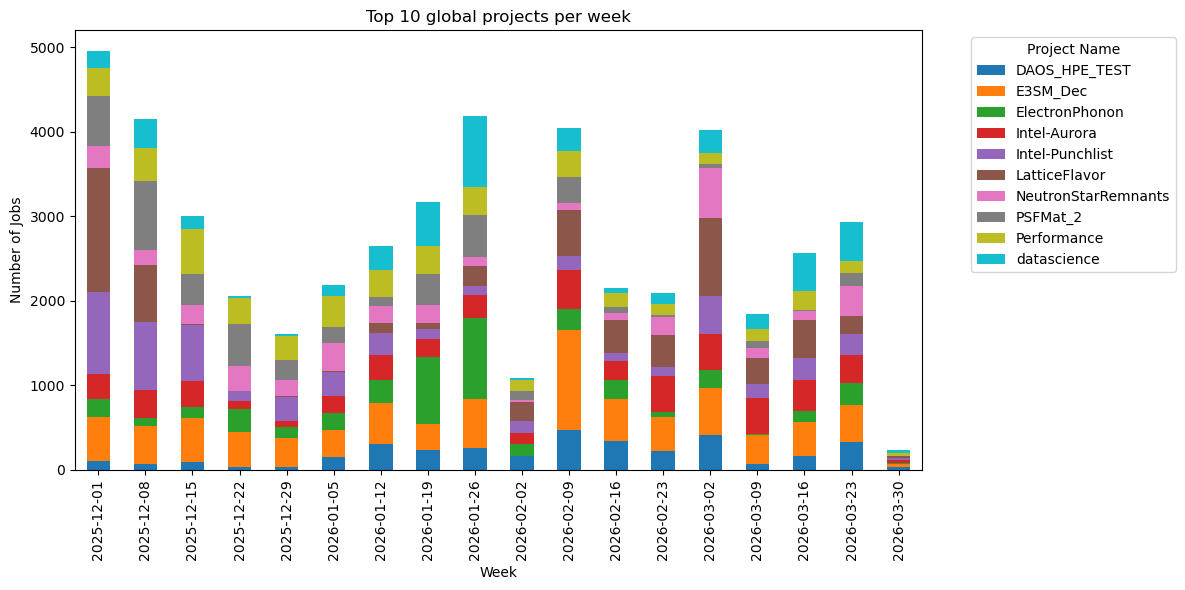

In [28]:

# Pivot the data for stacking
pivot_df = weekly_project_counts.pivot(
    index="week",
    columns="project_name",
    values="job_count"
).fillna(0)

# Plot stacked bar chart
pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Top 10 global projects per week")
plt.xlabel("Week")
plt.ylabel("Number of Jobs")
plt.legend(title="Project Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

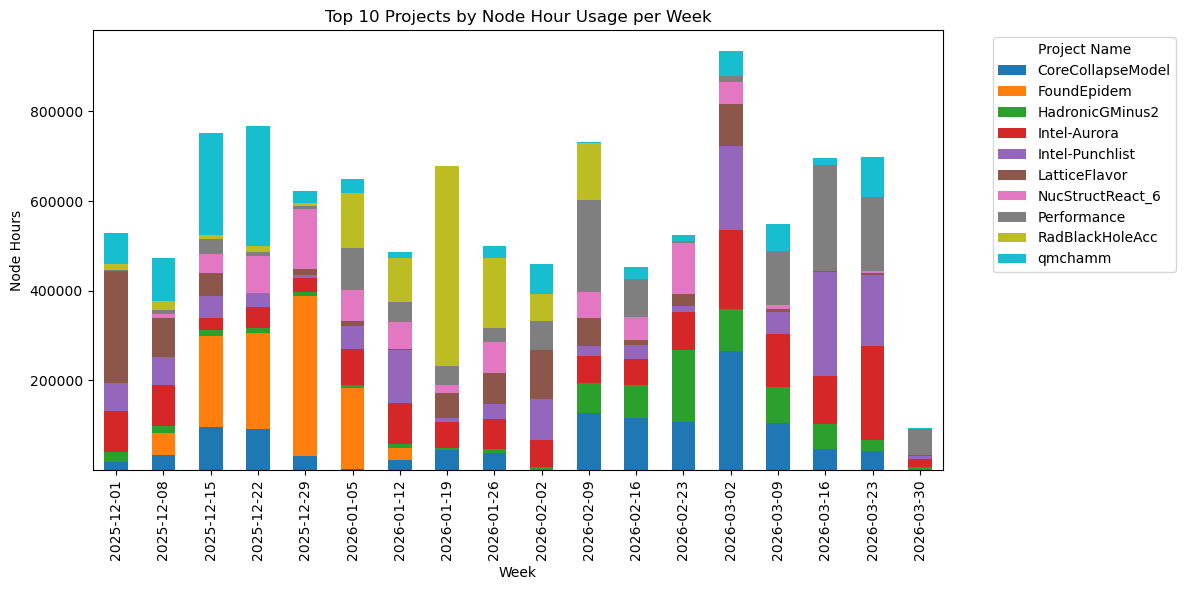

In [29]:
# plot top 10 project in terms of node hours usage


# Top 10 projects by node-hour usage
top_projects_by_nodehours = (
    new_df.groupby("project_name")["used_node_hours"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Weekly aggregation
weekly_project_usage = (
    new_df[new_df["project_name"].isin(top_projects_by_nodehours)]
    .groupby(["week", "project_name"])["used_node_hours"]
    .sum()
    .reset_index()
)



pivot_df = weekly_project_usage.pivot(
    index="week",
    columns="project_name",
    values="used_node_hours"
).fillna(0)

# Plot stacked bar chart
pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Top 10 Projects by Node Hour Usage per Week")
plt.xlabel("Week")
plt.ylabel("Node Hours")
plt.legend(title="Project Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()


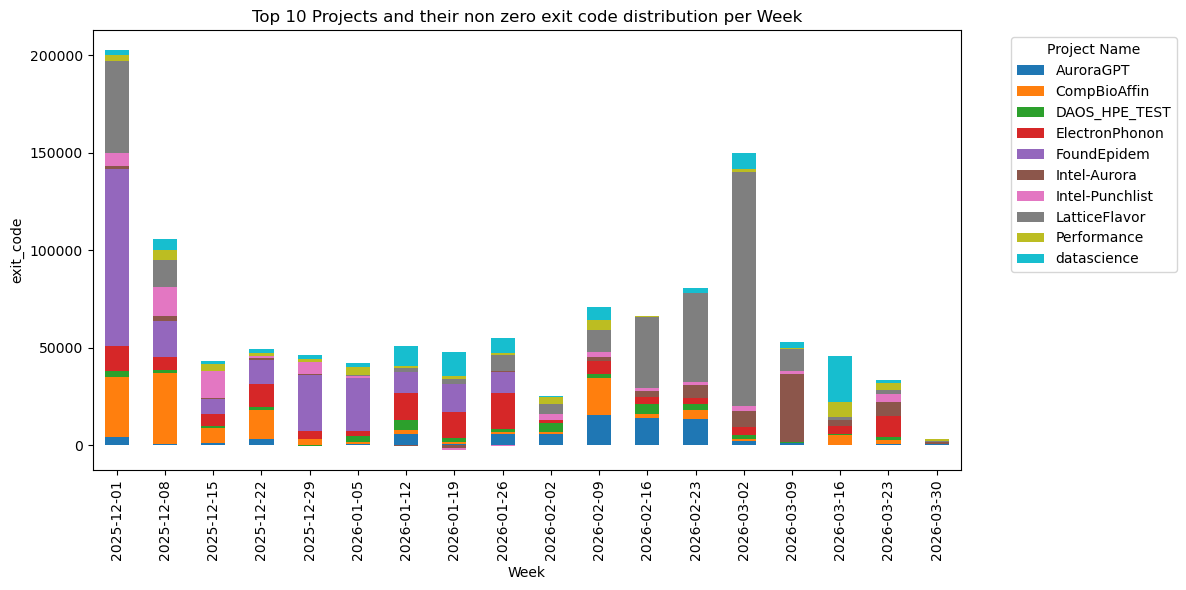

In [30]:
# plot top 10 project and their non zero exit code distribution
top_projects_by_nonzero_exitcode = (
    nonzero_df.groupby("project_name")["exit_code"]
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Weekly aggregation
weekly_project_usage = (
    new_df[new_df["project_name"].isin(top_projects_by_nonzero_exitcode)]
    .groupby(["week", "project_name"])["exit_code"]
    .sum()
    .reset_index()
)



pivot_df = weekly_project_usage.pivot(
    index="week",
    columns="project_name",
    values="exit_code"
).fillna(0)

# Plot stacked bar chart
pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Top 10 Projects and their non zero exit code distribution per Week")
plt.xlabel("Week")
plt.ylabel("exit_code")
plt.legend(title="Project Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()


In [31]:
#investigate failed jobs
failed_jobs=pd.read_csv('/Users/celsloaner/Desktop/Aurora_joblog/stabdb_failure_events.csv')
#failed_jobs = failed_jobs[failed_jobs['status'] == 'FAIL' ]
failed_jobs.head()

,Unnamed: 0,id,type,loc,ts,job_id,sig,bucket,blade_config_id,comments,source,bundle
0,11841497,31571657,failure,x4314c4s5b0n0,2025-12-01 00:20:39,NaN,Application_failures_PageFault,crash_segfault_kdump,NaN,NaN,"[""i915""]",x4314c4s5b0n0-2025-11-30T23_50_56-2025-12-01T0...
1,11841498,31571658,failure,x4312c5s3b0n0,2025-12-01 00:20:39,NaN,Application_failures_PageFault,crash_segfault_kdump,NaN,NaN,"[""i915""]",x4312c5s3b0n0-2025-11-30T23_51_02-2025-12-01T0...
2,11841505,31571667,failure,x4108c0s6b0n0,2025-12-01 02:16:30,NaN,Internal_SPR_Error,SPR_CPU,NaN,NaN,"[""Skt = 0x0::McBank = 0x1"", ""Skt = 0x0::McBank...",x4108c0s6b0n0-2025-12-01T01_57_45-2025-12-01T0...
3,11841513,31571675,failure,x4108c0s6b0n0,2025-12-01 03:06:51,NaN,Internal_SPR_Error,SPR_CPU,NaN,NaN,"[""Skt = 0x0::McBank = 0x1"", ""Skt = 0x0::McBank...",x4108c0s6b0n0-2025-12-01T02_58_45-2025-12-01T0...
4,11841535,31571699,failure,x4006c2s0b0n0,2025-12-01 10:46:45,NaN,PBS_epilogue_cxi_check_failed,PBS_epilogue,NaN,EXECJOB_END: cxi codeword test failed (job 817...,['cxi codeword'],NaN


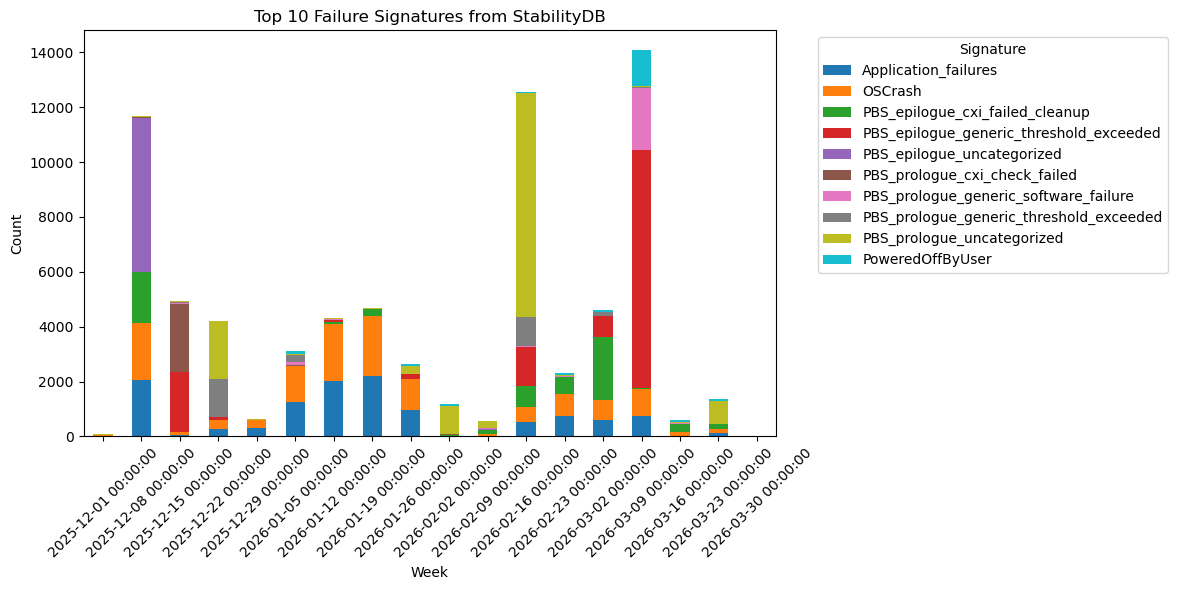

In [32]:
# Investigate failed jobs per week in StabDB
failed_jobs['ts'] = pd.to_datetime(failed_jobs['ts'])
failed_jobs['week'] = failed_jobs['ts'].dt.to_period('W').apply(lambda r: r.start_time)

# Get global top 10 sig
top10_sigs = failed_jobs['sig'].value_counts().head(10).index
filtered = failed_jobs[failed_jobs['sig'].isin(top10_sigs)]
weekly_counts = (
    filtered.groupby(['week', 'sig'])
    .size()
    .reset_index(name='count')
)
pivot = weekly_counts.pivot(index='week', columns='sig', values='count').fillna(0)

# Plot
pivot.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Top 10 Failure Signatures from StabilityDB")
plt.xlabel("Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='Signature', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [33]:

pbs_jobs=pd.read_csv('/Users/celsloaner/Desktop/Aurora_joblog/aurora_2026_preprocessed_jobdir.csv')
pbs_jobs.head()

,job_id,start_timestamp,end_timestamp,pbs_job_identifier,username,project_name,queue_name,runtime_seconds,nodes_used,used_node_hours,...,end_date_id,queued_date_id,walltime_seconds,queued_wait_seconds,job_dir,TASK_EXIT_CODES,FAILURE_CATEGORY_INTEL,FAILURE_CATEGORY_ALCF,stabilitydb_file,stabilitydb_failure
0,8207408,2026-01-13T01:43:57,2026-01-13T13:45:17,8207408.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,yuhang,DistortSD2,small,43216.0,700.0,8415.55554,...,20260113,20251212,43200.0,2751905,/run/aurora_bi/bi_data/aurora/job_data/2026011...,143,NaN,NaN,False,False
1,8207440,2026-01-13T02:20:06,2026-01-13T02:27:56,8207440.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,yuhang,DistortSD2,small,391.0,700.0,91.38885,...,20260113,20251212,43200.0,2752275,/run/aurora_bi/bi_data/aurora/job_data/2026011...,"134,143",NaN,NaN,False,False
2,8208375,2026-01-08T15:31:34,2026-01-09T03:35:12,8208375.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,jdominsk,XGC_aesp_CNDA,small,43337.0,960.0,11578.13328,...,20260109,20251212,43200.0,2328689,/run/aurora_bi/bi_data/aurora/job_data/2026010...,143,NaN,NaN,False,False
3,8208423,2026-01-13T01:43:57,2026-01-13T12:04:19,8208423.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,jdominsk,XGC_aesp_CNDA,small,37140.0,960.0,9925.86662,...,20260113,20251212,43200.0,2709064,/run/aurora_bi/bi_data/aurora/job_data/2026011...,"134,143",NaN,NaN,False,False
4,8210590,2026-01-01T13:04:06,2026-01-02T12:58:10,8210590.aurora-pbs-0001.hostmgmt.cm.aurora.alc...,danat,NeutronStarRemnants,nre-priority,85988.0,24.0,573.62666,...,20260102,20251214,86399.0,1572214,/run/aurora_bi/bi_data/aurora/job_data/2026010...,0,NaN,NaN,False,False


In [34]:
pbs_jobs[['job_id','stabilitydb_failure']]

,job_id,stabilitydb_failure
0,8207408,False
1,8207440,False
2,8208375,False
3,8208423,False
4,8210590,False
...,...,...
46783,8339703,False
46784,8339704,False
46785,8339707,False
46786,8339711,False


In [35]:
pbs_jobs.stabilitydb_failure.unique()

array(['False', "['PBS_epilogue_spr_hbm_memory_threshold_exceeded']",
       "['PVC_or_CPU_IVOC_Failure']",
       "['PBS_epilogue_spr_ddr_memory_threshold_exceeded']",
       "['PBS_epilogue_pvc_correctable_repairable']",
       "['PBS_epilogue_cxi_link_down']",
       "['hbm_controller_errors', 'mdfi_credit_overflow']",
       "['fatal_7_0x10_IDI_Parity', 'mdfi_credit_overflow', 'hbm_controller_errors']",
       "['fatal_7_others', 'mdfi_credit_overflow']", "['OSCrash']",
       "['Application_failures', 'OSCrash']", "['fatal_7_others']",
       "['fatal_7_multiple_quads']", "['PBS_epilogue_uncategorized']",
       "['PVC_SOC_Correctable_Error', 'hbm_controller_errors', 'mdfi_credit_overflow']",
       "['PBS_prologue_uncategorized']",
       "['Application_failures_PageFault']",
       "['hbm_controller_multi_errors', 'mdfi_credit_overflow']",
       "['general_singlebank_correctable_error', 'grf_fatal_singlesubslice_error', 'mdfi_credit_overflow']",
       "['PBS_epilogue_generic_s

In [36]:
#investigate failed jobs
failed_jobs=pd.read_csv('/Users/celsloaner/Desktop/Functions/weekly_nr_failed_jobs.csv')
failed_jobs = failed_jobs.loc[
    (failed_jobs["week"] >= "2025-12-01") &
    (failed_jobs["week"] <= "2026-03-31")
]
failed_jobs.tail()

,week,nr_failed_jobs
52,2025-12-29,29
53,2026-01-05,48
54,2026-01-12,43
55,2026-01-19,37
56,2026-01-26,14


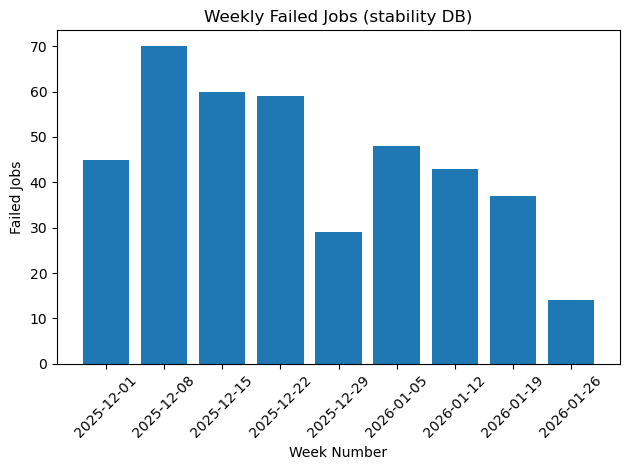

In [37]:
#plot weekly failed jobs
# Plot
plt.figure()
plt.bar(failed_jobs['week'], failed_jobs['nr_failed_jobs'])

plt.xlabel("Week Number")
plt.ylabel("Failed Jobs")
plt.title("Weekly Failed Jobs (stability DB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
weekly_usage = (
    new_df
    .groupby(["week", "project_name"])["used_node_hours"]
    .sum()
    .reset_index()
)

In [22]:
top10_per_week = (
    weekly_usage
    .sort_values(["week", "used_node_hours"], ascending=[True, False])
    .groupby("week")
    .head(10)
)



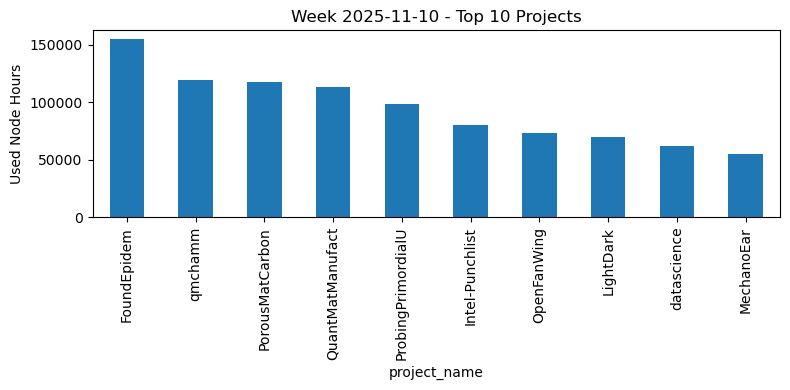

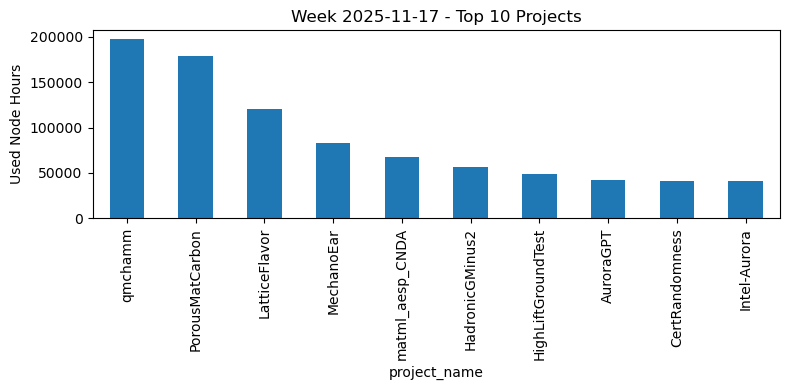

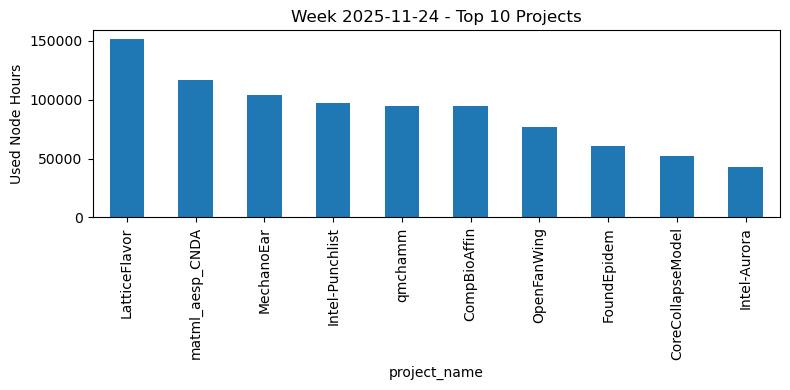

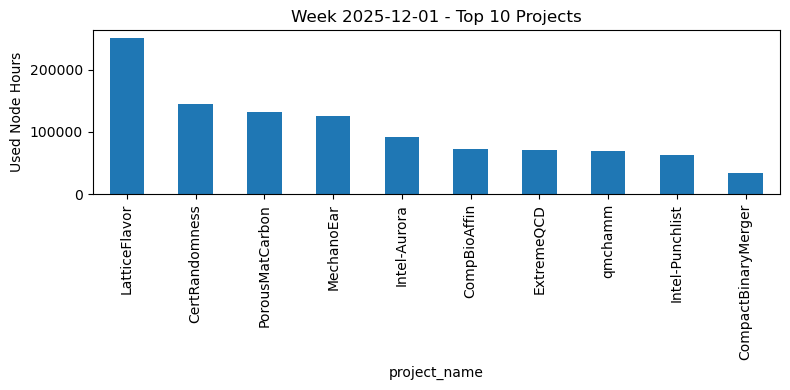

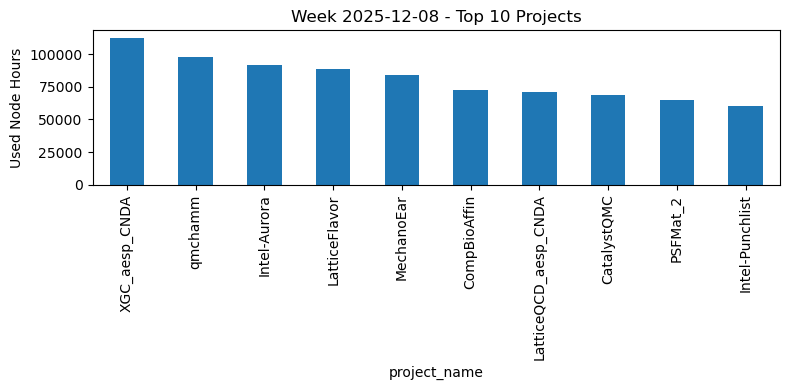

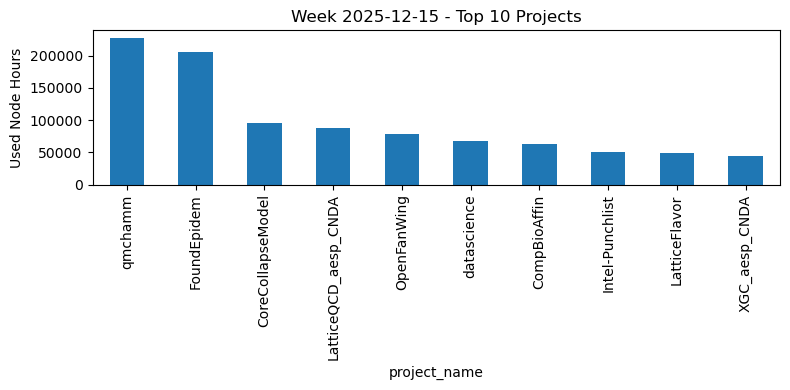

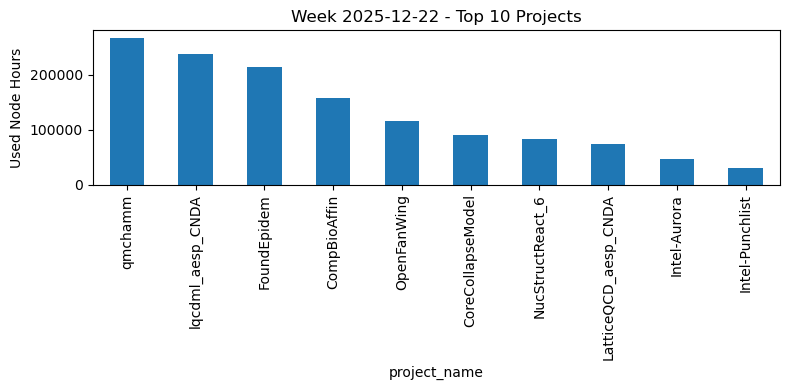

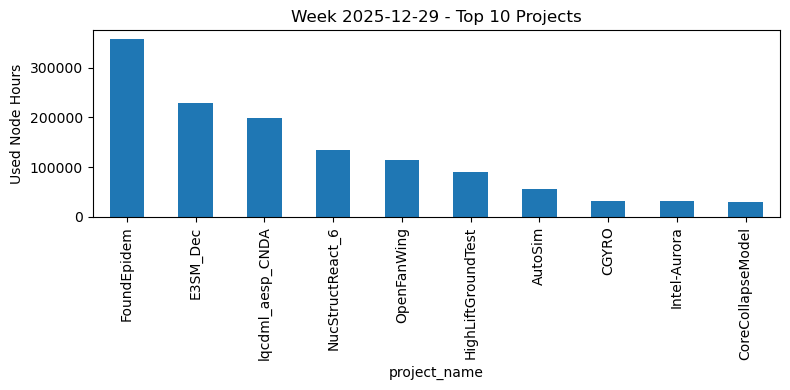

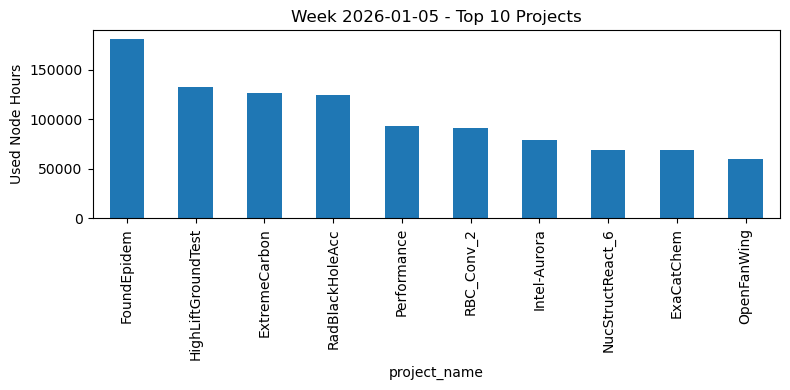

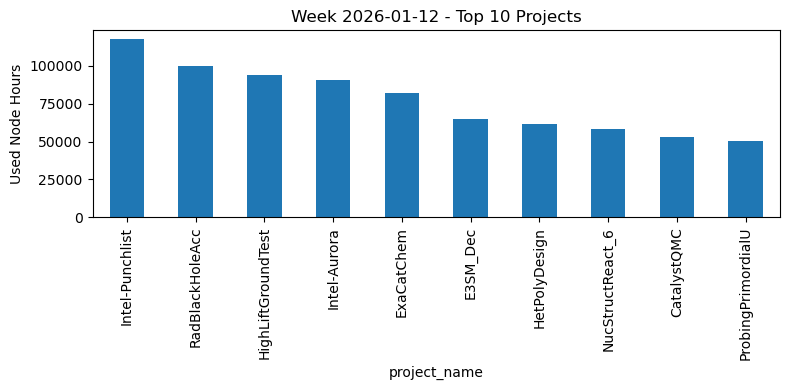

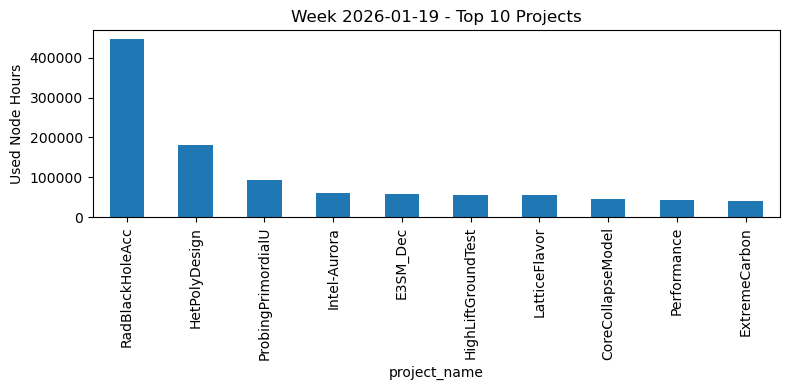

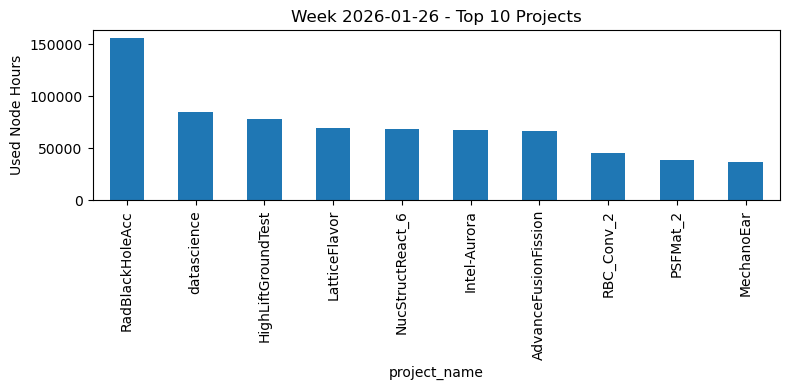

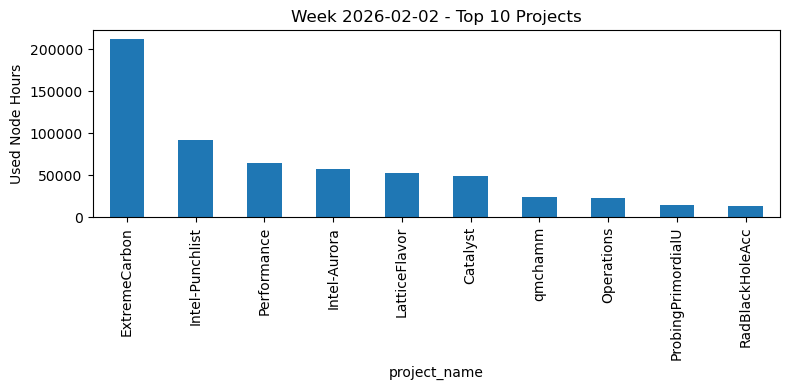

In [23]:
for week, group in top10_per_week.groupby("week"):
    group.set_index("project_name")["used_node_hours"].plot(
        kind="bar",
        title=f"Week {week} - Top 10 Projects",
        figsize=(8, 4)
    )
    plt.ylabel("Used Node Hours")
    plt.tight_layout()
    plt.show()
   